# ------------------------------------TASK 1 ---------------------------

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

data = pd.read_csv('iot_telemetry_data.csv', engine='python')
print(data.head())

             ts             device        co   humidity  light       lpg  \
0  1.594512e+09  b8:27:eb:bf:9d:51  0.004956  51.000000  False  0.007651   
1  1.594512e+09  00:0f:00:70:91:0a  0.002840  76.000000  False  0.005114   
2  1.594512e+09  b8:27:eb:bf:9d:51  0.004976  50.900000  False  0.007673   
3  1.594512e+09  1c:bf:ce:15:ec:4d  0.004403  76.800003   True  0.007023   
4  1.594512e+09  b8:27:eb:bf:9d:51  0.004967  50.900000  False  0.007664   

   motion     smoke       temp  
0   False  0.020411  22.700000  
1   False  0.013275  19.700001  
2   False  0.020475  22.600000  
3   False  0.018628  27.000000  
4   False  0.020448  22.600000  


In [ ]:
# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
ts          0
device      0
co          0
humidity    0
light       0
lpg         0
motion      0
smoke       0
temp        0
dtype: int64


In [ ]:
# Basic information about the dataset
print("\nDataset Info:")
data.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405184 entries, 0 to 405183
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   ts        405184 non-null  float64
 1   device    405184 non-null  object 
 2   co        405184 non-null  float64
 3   humidity  405184 non-null  float64
 4   light     405184 non-null  bool   
 5   lpg       405184 non-null  float64
 6   motion    405184 non-null  bool   
 7   smoke     405184 non-null  float64
 8   temp      405184 non-null  float64
dtypes: bool(2), float64(6), object(1)
memory usage: 22.4+ MB


In [ ]:
# Transforming boolean columns 'light' and 'motion' into integers
data['light'] = data['light'].astype(int)
data['motion'] = data['motion'].astype(int)

# convert unix time to time of day
from datetime import datetime, timedelta
start = datetime(1970, 1, 1)  # Unix epoch start time
data['datetime'] = data.ts.apply(lambda x: start + timedelta(seconds=x))
data = data.drop('ts', axis=1)

# Convert the 'datetime' column to a datetime object, and make datetime column into index column for convenience
data['datetime'] = pd.to_datetime(data['datetime'])
data.set_index('datetime', inplace=True)
data.head(5)

,device,co,humidity,light,lpg,motion,smoke,temp
datetime,,,,,,,,
2020-07-12 00:01:34.385975,b8:27:eb:bf:9d:51,0.004956,51.000000,0,0.007651,0,0.020411,22.700000
2020-07-12 00:01:34.735568,00:0f:00:70:91:0a,0.002840,76.000000,0,0.005114,0,0.013275,19.700001
2020-07-12 00:01:38.073573,b8:27:eb:bf:9d:51,0.004976,50.900000,0,0.007673,0,0.020475,22.600000
2020-07-12 00:01:39.589146,1c:bf:ce:15:ec:4d,0.004403,76.800003,1,0.007023,0,0.018628,27.000000
2020-07-12 00:01:41.761235,b8:27:eb:bf:9d:51,0.004967,50.900000,0,0.007664,0,0.020448,22.600000


In [ ]:
# Grouping data by 'device' and creating a separate DataFrame for each device
device_groups = data.groupby('device')

# Dictionary to store each device's DataFrame
device_df = {}

for device, group in device_groups:
    device_df[device] = group

In [ ]:
device_df.keys()

dict_keys(['00:0f:00:70:91:0a', '1c:bf:ce:15:ec:4d', 'b8:27:eb:bf:9d:51'])

## Data Overview

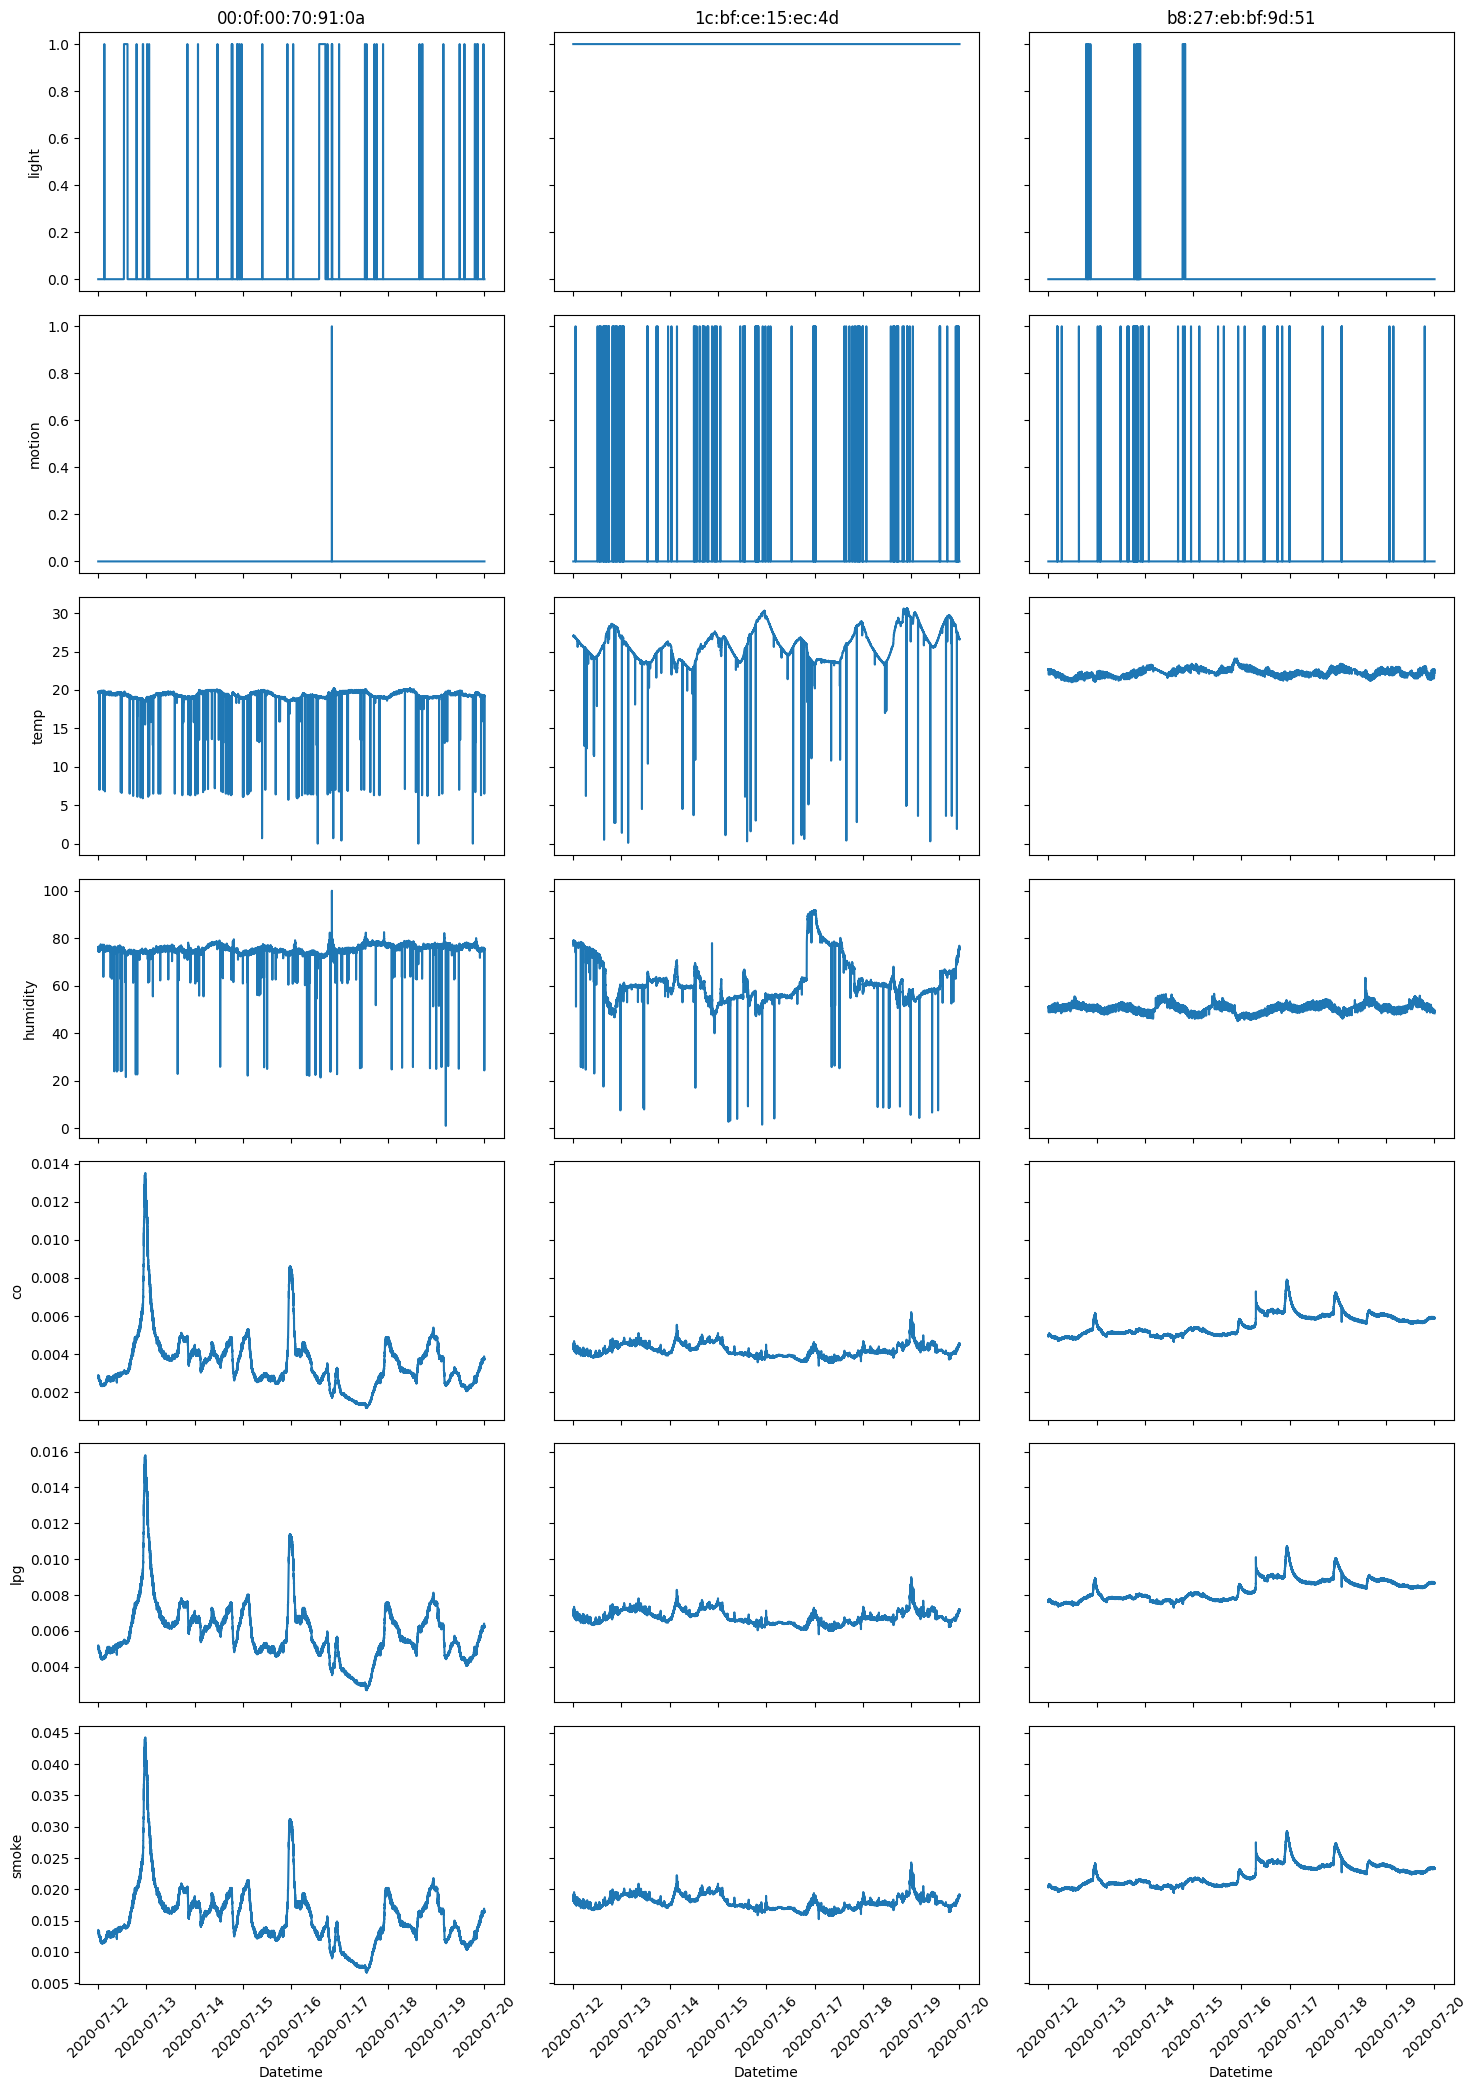

In [ ]:
def plot_device_sensors(device_df, undersample_rate=1):
    """
    Plot sensor data for each device with aligned axes.

    Args:
    - device_df (dict): Dictionary with device IDs as keys and DataFrames as values.
    - undersample_rate (int): Rate at which to undersample the data for plotting efficiency. Default is 1 (no undersampling).
    """

    # Sensors in the desired order
    sensors = ['light', 'motion', 'temp', 'humidity', 'co', 'lpg', 'smoke']

    # Number of devices and sensors
    num_devices = len(device_df)
    num_sensors = len(sensors)

    # Create a figure with subplots
    fig, axes = plt.subplots(nrows=num_sensors, ncols=num_devices, figsize=(num_devices * 5, num_sensors * 3), sharex='col', sharey='row')

    # Iterate through each device and sensor
    for j, (device_id, df) in enumerate(device_df.items()):
        # Undersample the data
        df_undersampled = df.iloc[::undersample_rate, :]

        for i, sensor in enumerate(sensors):
            # Plot each sensor in a separate subplot
            sns.lineplot(data=df_undersampled, x=df_undersampled.index, y=sensor, ax=axes[i, j])
            axes[i, j].tick_params(axis='x', rotation=45)  # Rotate x-axis labels

            # Set x and y labels
            if j == 0:  # Only set y-axis label for the first column
                axes[i, j].set_ylabel(sensor)
            if i == num_sensors - 1:  # Only set x-axis label for the bottom row
                axes[i, j].set_xlabel('Datetime')
            else:
                axes[i, j].set_xlabel('')

            # Set titles for the first row and first column
            if i == 0:
                axes[i, j].set_title(device_id)

    plt.tight_layout()
    plt.show()

plot_device_sensors(device_df, undersample_rate=2)

## Removing redundancies
From the overview, we can find that CO, lpg, and smoke readout are highly correlated. To confirm the correlation, we plot the correlation matrix to verify this observation.

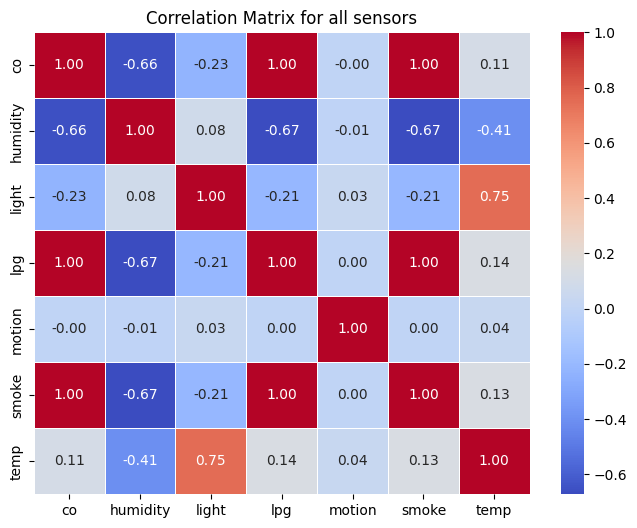

In [ ]:
# Drop the sensor column
corr_data = data.drop(['device'],axis=1)

# Compute the correlation matrix
corr_matrix = corr_data.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix for all sensors')
plt.show()

In [ ]:
# Iterating through the dictionary and removing 'lpg' and 'smoke' columns
for device_id, df in device_df.items():
    device_df[device_id] = df.drop(columns=['lpg', 'smoke'])

device_df

{'00:0f:00:70:91:0a':                                        device        co   humidity  light  \
 datetime                                                                    
 2020-07-12 00:01:34.735568  00:0f:00:70:91:0a  0.002840  76.000000      0   
 2020-07-12 00:01:46.869076  00:0f:00:70:91:0a  0.002938  76.000000      0   
 2020-07-12 00:02:02.785732  00:0f:00:70:91:0a  0.002905  75.800003      0   
 2020-07-12 00:02:11.476376  00:0f:00:70:91:0a  0.002938  75.800003      0   
 2020-07-12 00:02:15.289086  00:0f:00:70:91:0a  0.002840  76.000000      0   
 ...                                       ...       ...        ...    ...   
 2020-07-20 00:03:16.329782  00:0f:00:70:91:0a  0.003745  75.300003      0   
 2020-07-20 00:03:20.684223  00:0f:00:70:91:0a  0.003745  75.400002      0   
 2020-07-20 00:03:25.039890  00:0f:00:70:91:0a  0.003745  75.400002      0   
 2020-07-20 00:03:33.162015  00:0f:00:70:91:0a  0.003745  75.300003      0   
 2020-07-20 00:03:36.979522  00:0f:00:70:91

## Calculate sampling rates
In this grouped data, we can find that these several devices have different sampling rate, so we will calculate them here for later use.

In [ ]:
# Function that calculate the sampling rate
def calculate_sampling_stats(device_df):
    sampling_stats = {}

    for device_id, df in device_df.items():
        # Calculate time differences between consecutive data points
        time_diffs = df.index.to_series().diff().dropna()

        # Convert time differences to a consistent unit, e.g., seconds
        time_diffs_in_seconds = time_diffs.dt.total_seconds()

        # Calculate mean and standard deviation
        mean_sampling_rate = time_diffs_in_seconds.mean()
        std_sampling_rate = time_diffs_in_seconds.std()

        # Store in dictionary
        sampling_stats[device_id] = {'mean': mean_sampling_rate, 'std': std_sampling_rate}

    return sampling_stats

# Calculate sampling stats for each device
device_sampling_stats = calculate_sampling_stats(device_df)
for device, stats in device_sampling_stats.items():
    print(f"Device {device} - Mean Sampling Rate: {stats['mean']}s, Std Dev: {stats['std']}s")

Device 00:0f:00:70:91:0a - Mean Sampling Rate: 6.182787879460532s, Std Dev: 2.5363540690275266s
Device 1c:bf:ce:15:ec:4d - Mean Sampling Rate: 6.526965254047981s, Std Dev: 3.0185357592392035s
Device b8:27:eb:bf:9d:51 - Mean Sampling Rate: 3.6880388281568415s, Std Dev: 0.052234523971958435s


## Environmental Characteristics
Now we check the temperature and humidity of each device to see if they match with the dataset description.

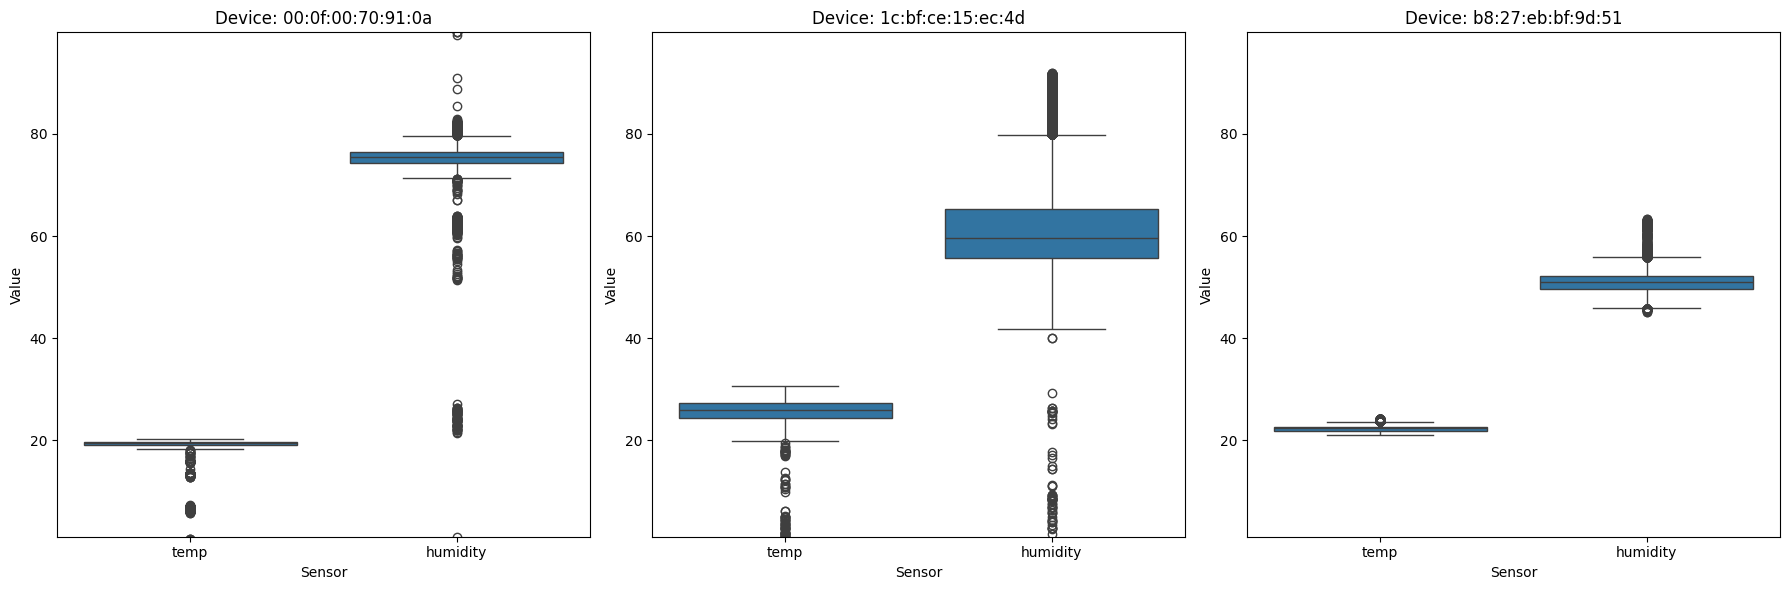

In [ ]:
def plot_sensor_boxplots(device_df, sensors=['temp', 'humidity']):
    """
    Generate box plots for specified sensors from each device with same y-axis scale.

    Args:
    - device_df (dict): Dictionary with device IDs as keys and DataFrames as values.
    - sensors (list): List of sensors to plot.
    """

    num_devices = len(device_df)
    fig, axes = plt.subplots(nrows=1, ncols=num_devices, figsize=(num_devices * 6, 6))

    # Determine the global min and max values across all devices for each sensor
    global_min = {sensor: float('inf') for sensor in sensors}
    global_max = {sensor: float('-inf') for sensor in sensors}

    for df in device_df.values():
        for sensor in sensors:
            global_min[sensor] = min(global_min[sensor], df[sensor].min())
            global_max[sensor] = max(global_max[sensor], df[sensor].max())

    # Plot the box plots
    for j, (device_id, df) in enumerate(device_df.items()):
        data_to_plot = df[sensors].melt(var_name='Sensor', value_name='Value')
        sns.boxplot(x='Sensor', y='Value', data=data_to_plot, ax=axes[j])
        axes[j].set_title(f'Device: {device_id}')

        # Set the same y-axis limits for each subplot
        for i, sensor in enumerate(sensors):
            axes[j].set_ylim([global_min[sensor], global_max[sensor]])

    plt.tight_layout()
    plt.show()

plot_sensor_boxplots(device_df)

Consistent with the dataset's description, it is evident that the three devices are situated in distinct environments, each characterized by unique temperature and humidity profiles. Here we use the first two digits of device labels to refer to each device.

**Device 00**: This environment is cool and humid, indicative of a well-controlled indoor setting. Such conditions suggest a stable and consistent environmental control system.

**Device 1c**: This environment is warm and moderately humid, with significant variation. The fluctuating readings indicate a less well-controlled environment, where temperature and humidity are subject to natural variations or human activity.

**Device b8**: This environment is warm and dry, and it also appears to be well-controlled. The consistent readings suggest an stable environmental control, similar to Device 00, but with a different temperature and humifty settings.

These observations lead to a preliminary hypothesis: All devices are likely situated indoors, given their stable environmental readings. However, **Device 1c, with its more variable data, seems to be located in an environment with regular human activity**. Moreover, it is under a constant lighting (indicated by the light sensor shown later). We can hypothesize that Device 1c is located in a workshop with constant usage, while the other two are located in places like storage areas with much less frequent usage and stable environmental control. Confirming this hypothesis necessitates further analysis, particularly a detailed examination of daily readouts.

## Binary Data Processing
Moving forward, our analysis shifts focus to the motion and light sensor readouts.

Given the binary nature of this data, which does not readily convey the intensity of sensor activity, we will implement a rolling average. This approach will smooth out the data epochs, transforming the binary readouts into a more continuous and interpretable measure of sensor activity frequency.

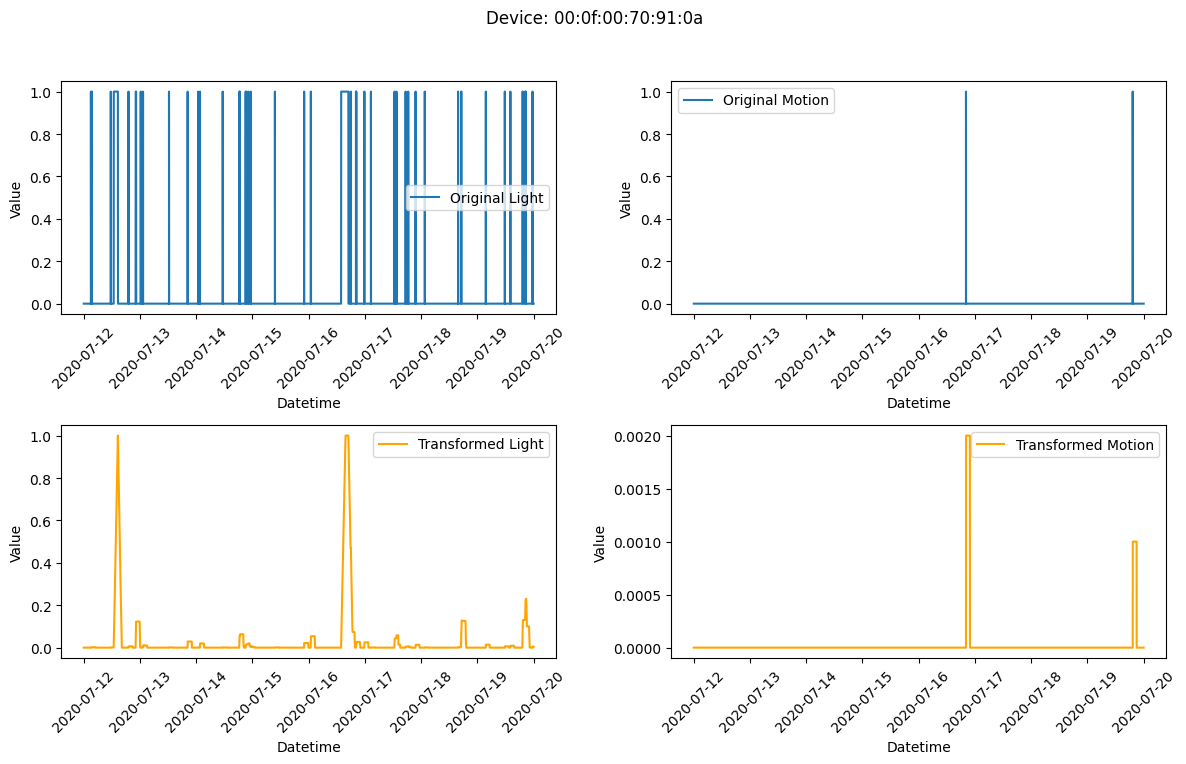

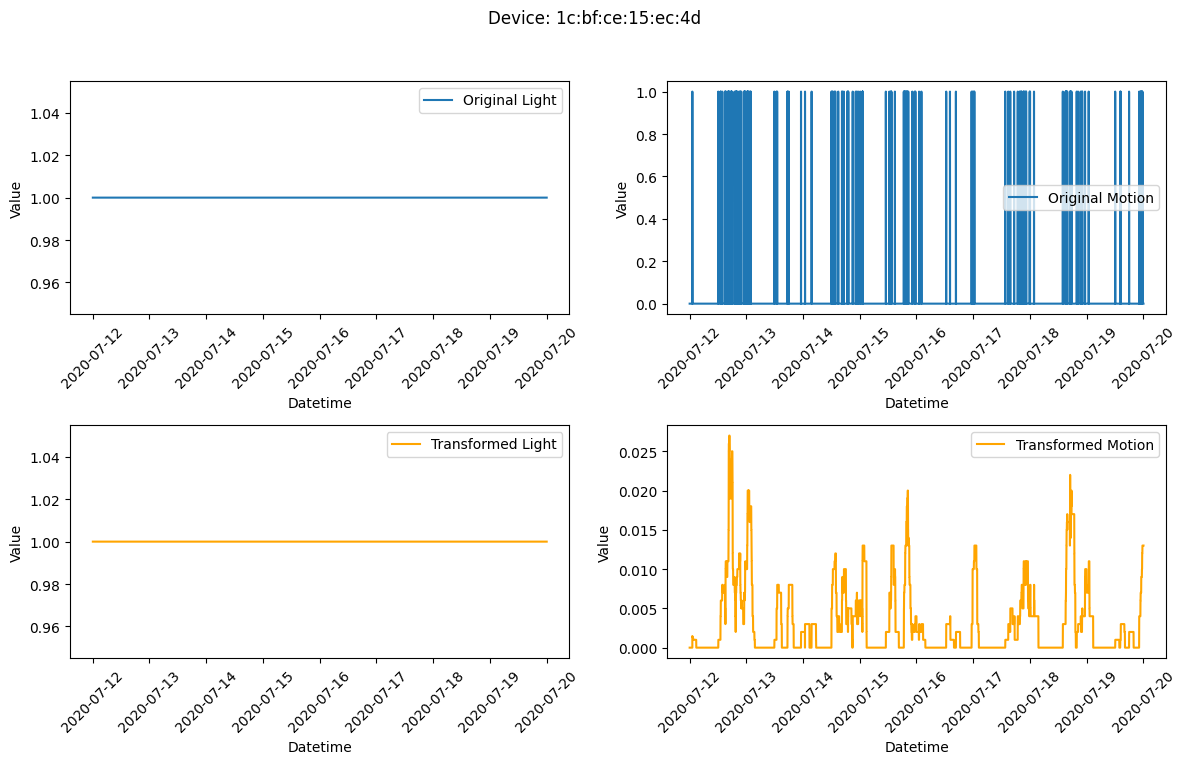

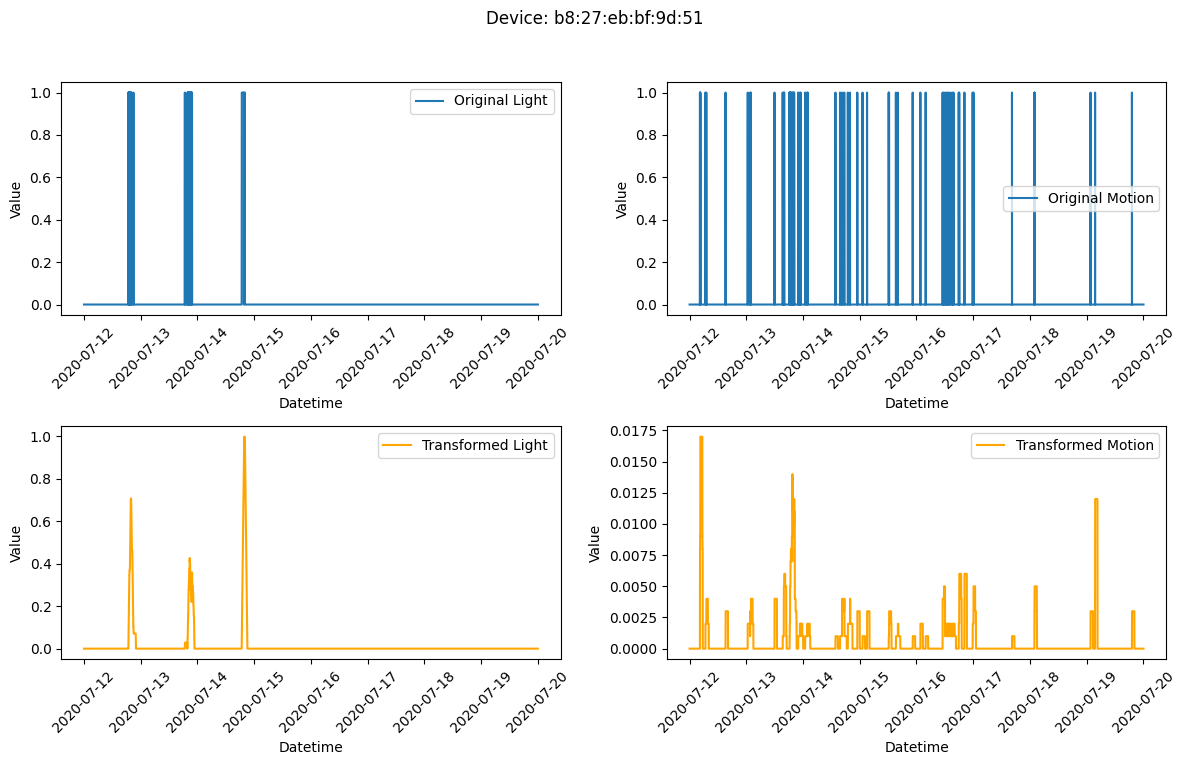

In [ ]:
def transform_binary_to_frequency(df, window_size):
    """
    Transform binary signals to frequency rates using rolling window mean.

    Args:
    - df (DataFrame): DataFrame containing binary signals.
    - window_size (int): Size of the rolling window.

    Returns:
    - DataFrame: Transformed DataFrame.
    """
    df_transformed = df.rolling(window=window_size, min_periods=1).mean()
    return df_transformed

def plot_transformed_data(device_df, window_size):
    """
    Plot original and transformed binary signals.

    Args:
    - device_df (dict): Dictionary with device IDs as keys and DataFrames as values.
    - window_size (int): Size of the rolling window for transformation.
    """

    for device_id, df in device_df.items():
        # Transform binary signals
        df_transformed = transform_binary_to_frequency(df[['light', 'motion']], window_size)

        # Plotting
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
        fig.suptitle(f"Device: {device_id}")

        # Original Data
        axes[0, 0].plot(df.index, df['light'], label='Original Light')
        axes[0, 1].plot(df.index, df['motion'], label='Original Motion')

        # Transformed Data
        axes[1, 0].plot(df_transformed.index, df_transformed['light'], label='Transformed Light', color='orange')
        axes[1, 1].plot(df_transformed.index, df_transformed['motion'], label='Transformed Motion', color='orange')

        # Setting labels
        for i in range(2):
            for j in range(2):
                axes[i, j].set_xlabel('Datetime')
                axes[i, j].set_ylabel('Value')
                axes[i, j].legend()
                axes[i, j].tick_params(axis='x', rotation=45)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

window_size = 1000 # Adjustable until a sweet spot is found
plot_transformed_data(device_df, window_size)


### Autocorrelation - Detecting Seasonality
The graphs display the light and motion sensor data before and after applying a rolling average, transforming the data from binary to a continuous format. This transformed data is then reintegrated into the original grouped dataframe.

Next, we use the previously calculated sampling rates to generate autocorrelation plots so that we can observe the seasonal patterns within the dataset.

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:457: RuntimeWarning: invalid value encountered in scalar divide
  return ((data[: n - h] - mean) * (data[h:] - mean)).sum() / n / c0


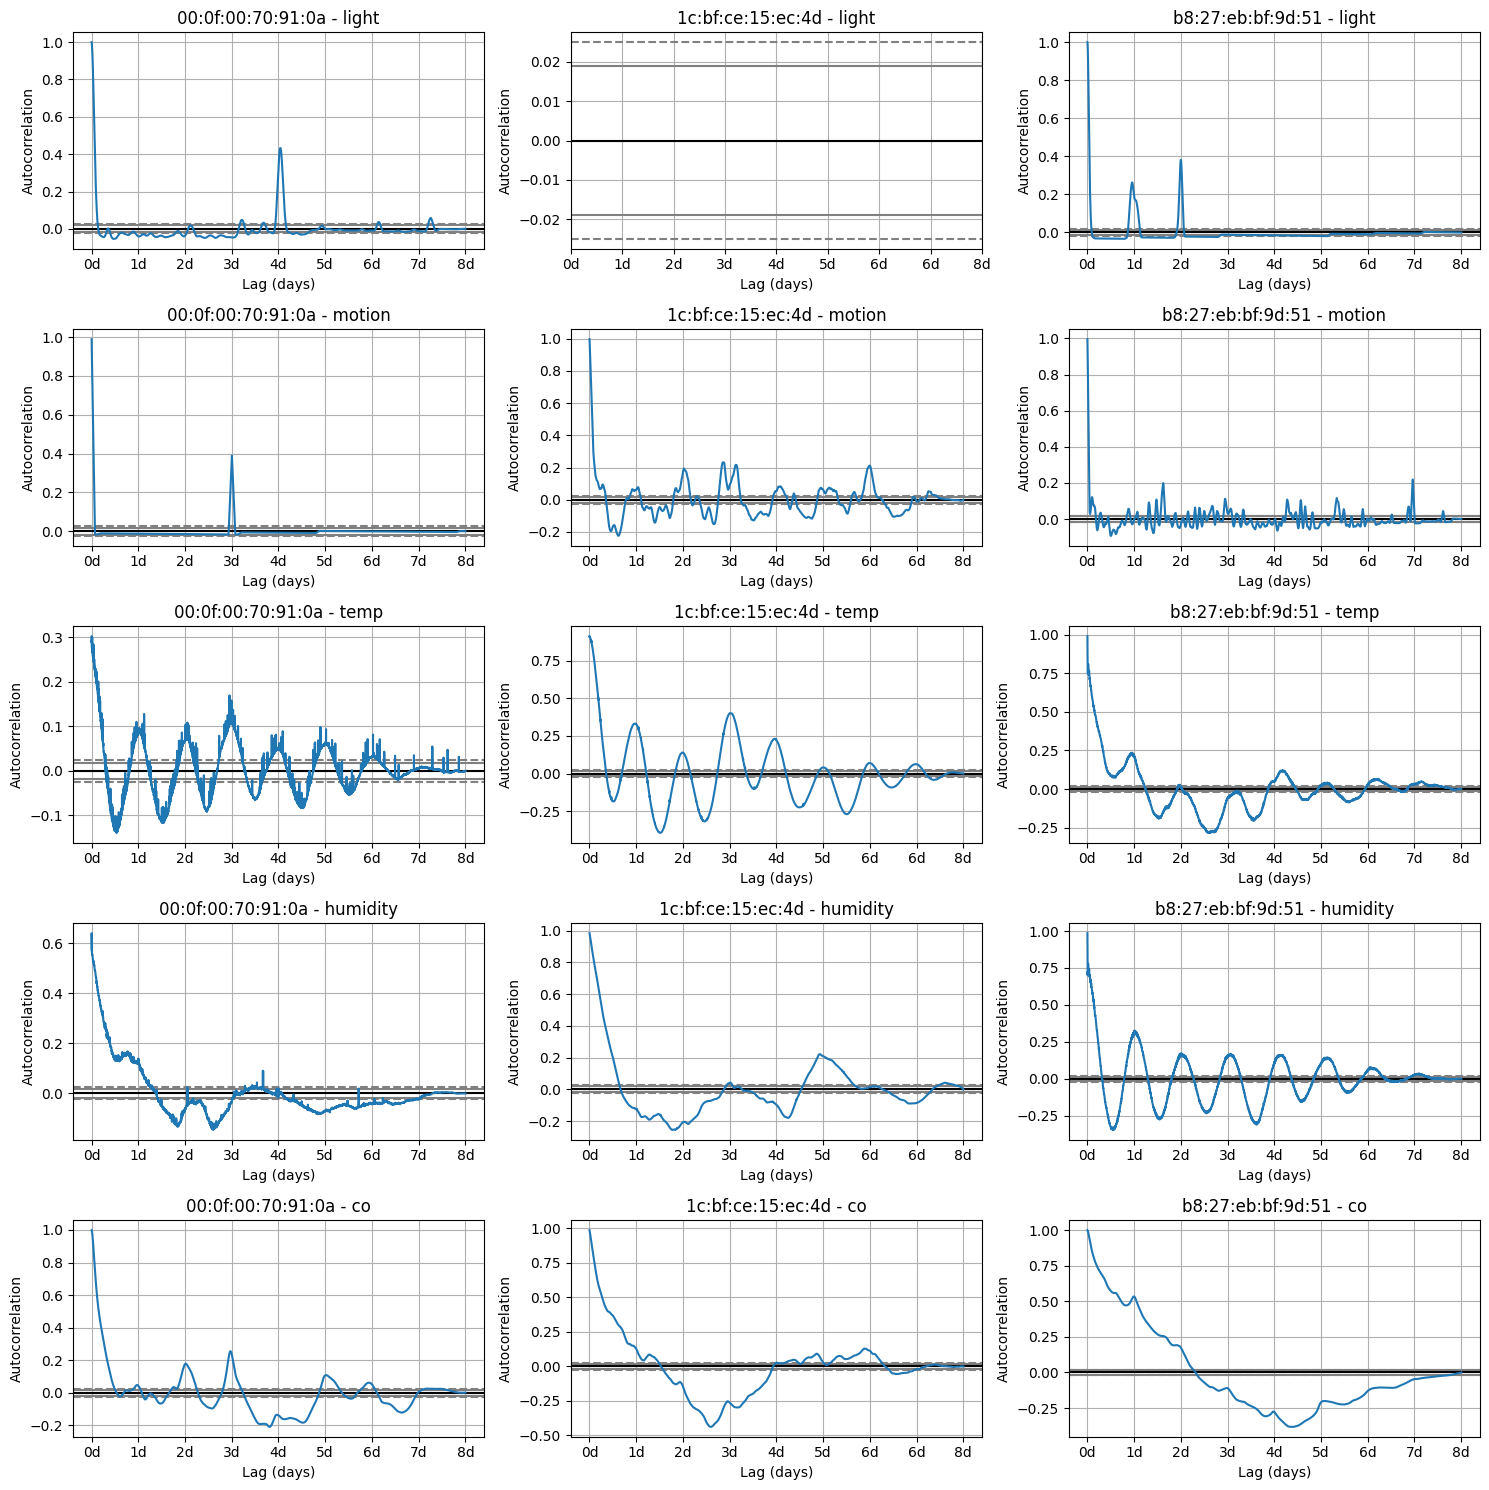

In [ ]:
def plot_autocorrelation(device_df, undersample_rate=1, sampling_rates=None):
    """
    Generate autocorrelation plots for all sensors in all devices.

    Args:
    - device_df (dict): Dictionary with device IDs as keys and DataFrames as values.
    - undersample_rate (int): Rate at which to undersample the data for plotting efficiency.
    - sampling_rates (dict): Dictionary with device IDs as keys and average sampling rates as values.
    """

    # Sensors in the desired order
    sensors = ['light', 'motion', 'temp', 'humidity', 'co']

    # Number of devices and sensors
    num_devices = len(device_df)
    num_sensors = len(sensors)

    # Seconds in a day
    seconds_in_day = 24 * 60 * 60

    # Create a figure with subplots
    fig, axes = plt.subplots(nrows=num_sensors, ncols=num_devices, figsize=(num_devices * 5, num_sensors * 3))

    # Iterate through each device and sensor
    for j, (device_id, df) in enumerate(device_df.items()):
        # Calculate number of samples in a day
        samples_per_day = seconds_in_day / (sampling_rates[device_id] * undersample_rate)

        # Undersample the data
        df_undersampled = df.iloc[::undersample_rate, :]

        for i, sensor in enumerate(sensors):
            # Create autocorrelation plot for each sensor
            autocorrelation_plot(df_undersampled[sensor], ax=axes[i][j])
            axes[i][j].set_title(f'{device_id} - {sensor}')
            axes[i][j].set_xlabel('Lag (days)')
            axes[i][j].set_ylabel('Autocorrelation')

            # Adjust x-axis to represent days
            max_lag = df_undersampled[sensor].shape[0]
            xticks = np.arange(0, max_lag, samples_per_day)
            xticklabels = [f"{int(lag/samples_per_day)}d" for lag in xticks]
            axes[i][j].set_xticks(xticks)
            axes[i][j].set_xticklabels(xticklabels)

    plt.tight_layout()
    plt.show()

# Apply the transformation to binary data
window_size = 1000
for device_id in device_df:
    device_df[device_id][['light', 'motion']] = transform_binary_to_frequency(device_df[device_id][['light', 'motion']], window_size)

# Sampling rates for each device
sampling_rates = {
    '00:0f:00:70:91:0a': 6.182787879460532,
    '1c:bf:ce:15:ec:4d': 6.526965254047981,
    'b8:27:eb:bf:9d:51': 3.6880388281568415
}

plot_autocorrelation(device_df, undersample_rate=10, sampling_rates=sampling_rates)

All temperature sensors display daily seasonality, albeit with varying intensities.
Device 1c-temperature stands out with the strongest seasonality, marked by high correlation factors and good signal-to-noise ratios. The pronounced seasonality in Device 1c coincides with daily human activity within its environment. Interestingly, this particular correlation pattern is not present in the other two devices.

Regarding humidity, each environment demonstrates unique trends. In the Device 00 setting, there is an absence of noticeable daily seasonality. In contrast, Device 1c shows a vague bi-daily pattern, indicating more complex environmental dynamics. Device b8, on the other hand, experiences regular daily fluctuations in humidity.

### Daily trends
With the observation of a daily pattern, we analyze and compare the daily variations across all devices.

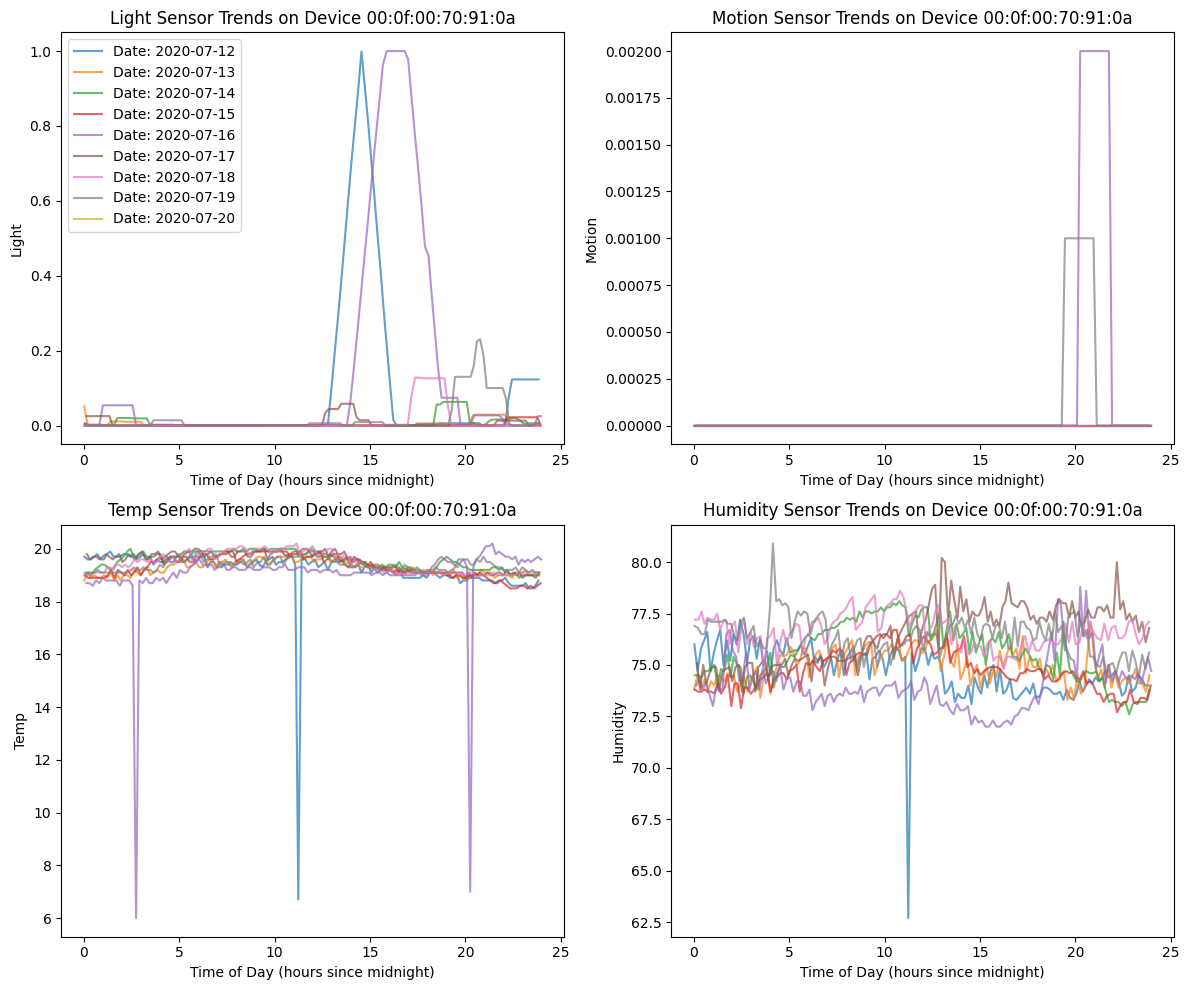

In [ ]:
def convert_time_to_hours(time_obj):
    """
    Convert a time object to hours since midnight.

    Args:
    - time_obj (datetime.time): Time object to convert.

    Returns:
    - float: Number of hours since midnight.
    """
    return time_obj.hour + time_obj.minute / 60 + time_obj.second / 3600

def plot_daily_trends_for_sensors(device_df, device_id, sensors, undersample_rate=100, window_size=1):
    """
    Plot daily trends of multiple sensors from a device in a 2x2 matrix with legends indicating dates.

    Args:
    - device_df (dict): Dictionary with device IDs as keys and DataFrames as values.
    - device_id (str): The ID of the device to plot.
    - sensors (list): List of sensors to plot.
    - undersample_rate (int): Rate at which to undersample the data.
    - window_size (int): Window size for moving average.
    """
    df = device_df[device_id]

    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    for i, sensor in enumerate(sensors):
        # Undersample and apply moving average
        df_resampled = df.iloc[::undersample_rate, :]
        df_smoothed = df_resampled[sensor].rolling(window=window_size, min_periods=1).mean()

        # Group by date and plot each day's data
        for date, group in df_smoothed.groupby(df_smoothed.index.date):
            # Convert index time to hours
            hours_since_midnight = [convert_time_to_hours(t) for t in group.index.time]
            axes[i].plot(hours_since_midnight, group, alpha=0.7, label=f'Date: {date}')

        axes[i].set_title(f'{sensor.capitalize()} Sensor Trends on Device {device_id}')
        axes[i].set_xlabel('Time of Day (hours since midnight)')
        axes[i].set_ylabel(f'{sensor.capitalize()}')
        if i == 0:
            axes[i].legend()

    # Adjust layout and show plot
    fig.tight_layout()
    plt.show()

sensors = ['light', 'motion', 'temp', 'humidity']
plot_daily_trends_for_sensors(device_df, '00:0f:00:70:91:0a', sensors)


### Device 00
Consistent with our previous observations, the temperature and humidity in the Device 00 environment appear to be well-controlled.
Light and motion activities are rare and predominantly observed during afternoon and nighttime.

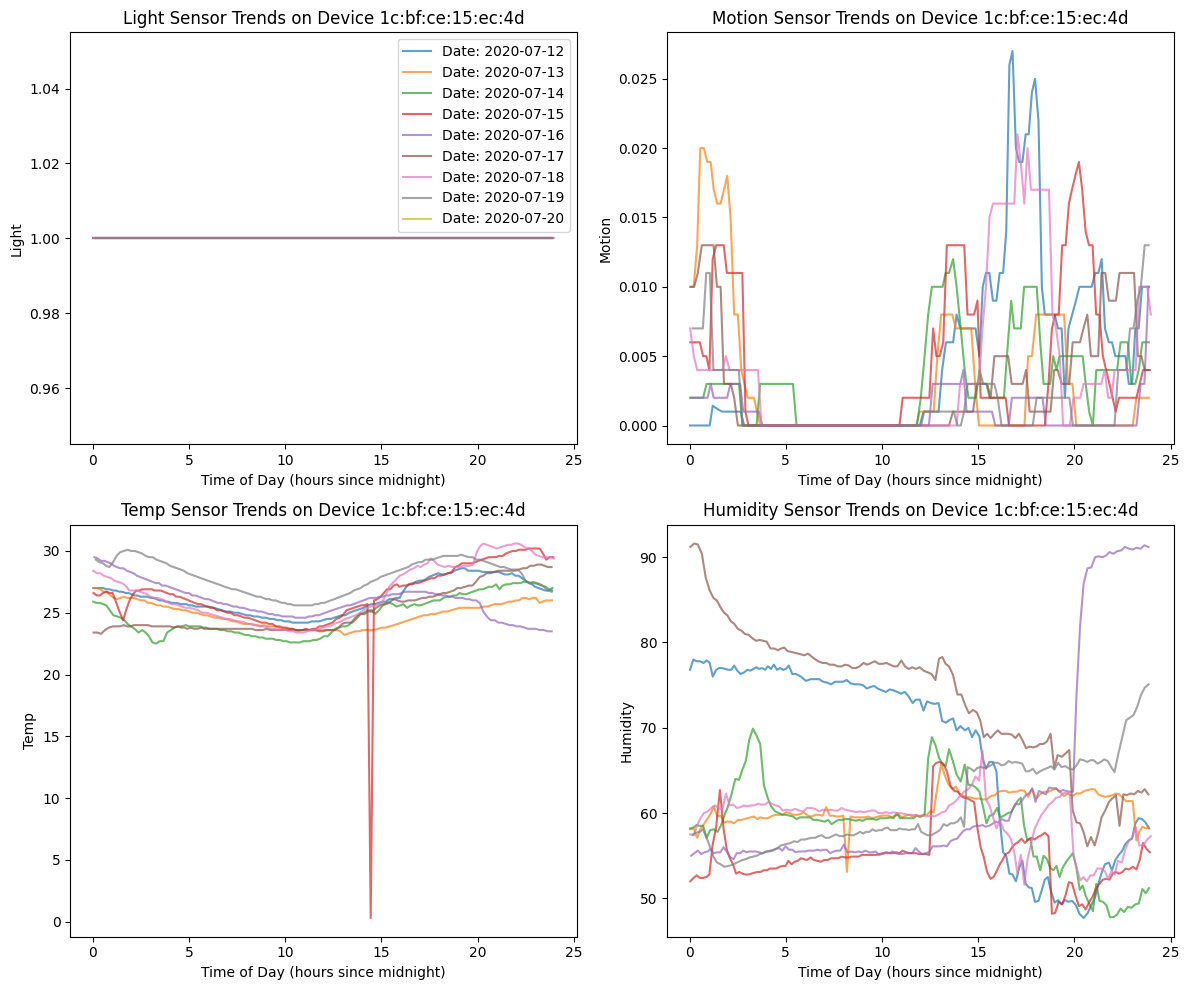

In [ ]:
plot_daily_trends_for_sensors(device_df, '1c:bf:ce:15:ec:4d', sensors)

### Device 1c
Device 1c displays a distinct pattern compared to Device 00, with a noticeable daily fluctuations in temperature. This device records the coolest temperatures around noon, with an increase towards the night. This is a pattern opposite to natural temperature cycle. Moreover, human activity also concentrate on these periods. Therefore, such a pattern suggests a causal relationship between human activity and temperature dynamics within this environment, consistent with the seasonality observation.

One can make assumption about this environment, say, a workshop in constant use. Another supporting evidence is the constant lighting condition.

Additionally, the variability in humidity levels also suggests that the environment control here is less stringent, contrasting with the more stable environments observed in other devices. Based on these, we can imagine that the other two environments may be storage room with well-controlled environment and less frequent human activity.

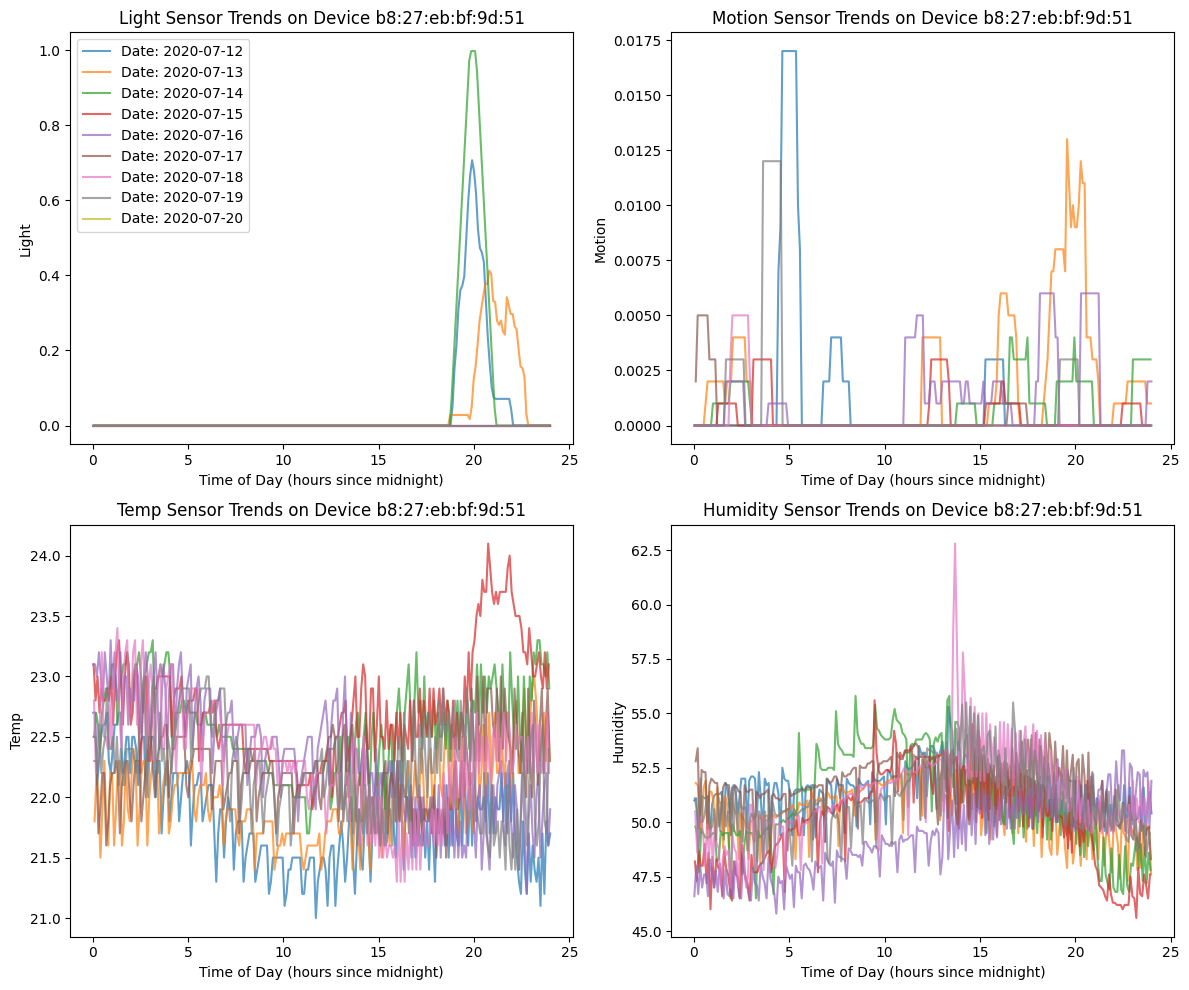

In [ ]:
plot_daily_trends_for_sensors(device_df, 'b8:27:eb:bf:9d:51', sensors)

### Device b8
The light and motion sensor readings suggest that human activity tends to avoid the noon hours, instead concentrating during the afternoon and nighttime. The correlation between temperature and human activity is similar with the workshop area where Device 1c is located. However, the human activity is too random for any pattern to emerge in the autocorrelation plot.

The environmental stability of Device b8 closely mirrors that of Device 00. A key distinction, however, lies in the high-frequency features in the data, in contrast to the high-intensity peaks observed in the other two devices. This difference is also presence in the humidity readings.

The detailed sensor readout of Device b8, which is free of high-intensity noise and rich in periodic features, could be attributed to its sampling frequency being twice that of the other devices, enabling a finer resolution of data capture. Alternatively, the variation might also due to the devices being exposed to varying environmental influences, such as vibrations from human activities or mechanical operations. These factors could significantly affect the sensor outputs and need to be considered when interpreting the data.

Ref:

## Ref:
https://www.kaggle.com/code/chaozhuang/iot-telemetry-sensor-data-analysis/notebook

https://www.kaggle.com/datasets/garystafford/environmental-sensor-data-132k

# -------------------------TASK 4------------------------------------

# Temperature Anomaly detection in Device 00 using Isolation Forest

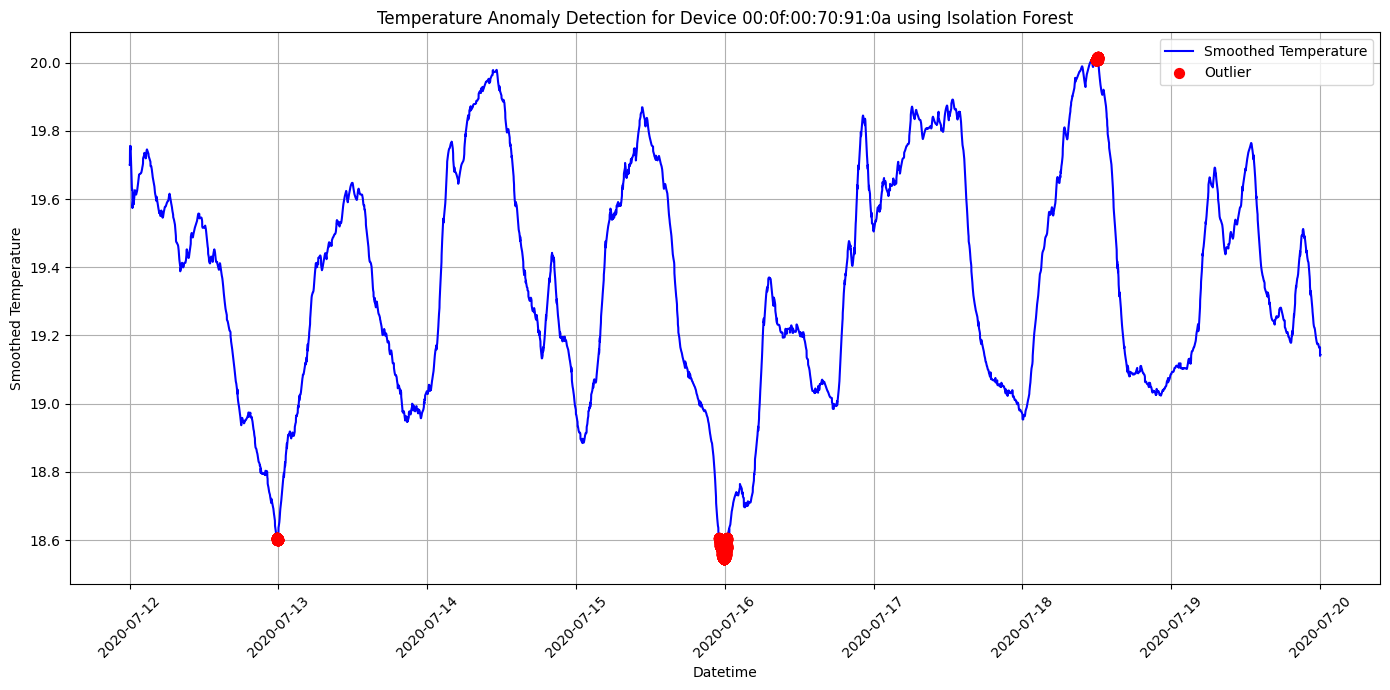

In [40]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Ensure 'device_df' is defined. This block re-creates it if it's not found,
# assuming 'data' is already loaded and preprocessed from previous cells.
if 'device_df' not in globals():
    print("Warning: 'device_df' not found. Recreating it from 'data'. Please ensure 'data' is correctly loaded and preprocessed by running previous cells.")
    # Grouping data by 'device' and creating a separate DataFrame for each device
    device_groups = data.groupby('device')
    device_df = {}
    for device, group in device_groups:
        device_df[device] = group
    # Re-apply the column drops done in Nr9qwEaR5rNH
    for device_id, df in device_df.items():
        cols_to_drop = [col for col in ['lpg', 'smoke'] if col in df.columns]
        if cols_to_drop:
            device_df[device_id] = df.drop(columns=cols_to_drop)



# Select data for device '00:0f:00:70:91:0a' and 'temp' sensor
device_id_to_analyze = '00:0f:00:70:91:0a' #'1c:bf:ce:15:ec:4d'#
temp_data = device_df[device_id_to_analyze]['temp'] # Corrected to 'temp' from 'motion'

# Apply rolling mean smoothing to the temperature data
# Using a window size of 1000, similar to the binary data transformation
window_size = 1000
smoothed_temp = temp_data.rolling(window=window_size, min_periods=1).mean().dropna()

# Prepare data for Isolation Forest (needs a 2D array)
X = smoothed_temp.values.reshape(-1, 1)


# Initialize and train the Isolation Forest model
# contamination is the proportion of outliers in the data set
iso_forest = IsolationForest(random_state=42, contamination=0.01)
iso_forest.fit(X)

# Predict anomalies (-1 for outliers, 1 for inliers)
anomalies = iso_forest.predict(X)

# Add anomaly predictions back to the smoothed_temp series for plotting
smoothed_temp_anomalies = smoothed_temp.copy()
smoothed_temp_anomalies = pd.DataFrame(smoothed_temp_anomalies)
smoothed_temp_anomalies['anomaly'] = anomalies

# Plot the smoothed temperature data and highlight outliers
plt.figure(figsize=(14, 7))
plt.plot(smoothed_temp_anomalies.index, smoothed_temp_anomalies['temp'], label='Smoothed Temperature', color='blue')

# Plot outliers
outliers = smoothed_temp_anomalies[smoothed_temp_anomalies['anomaly'] == -1]
plt.scatter(outliers.index, outliers['temp'], color='red', label='Outlier', s=50, zorder=3)

plt.title(f'Temperature Anomaly Detection for Device {device_id_to_analyze} using Isolation Forest')
plt.xlabel('Datetime')
plt.ylabel('Smoothed Temperature')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Motion Anomaly detection in Device 00 using Isolation Forest

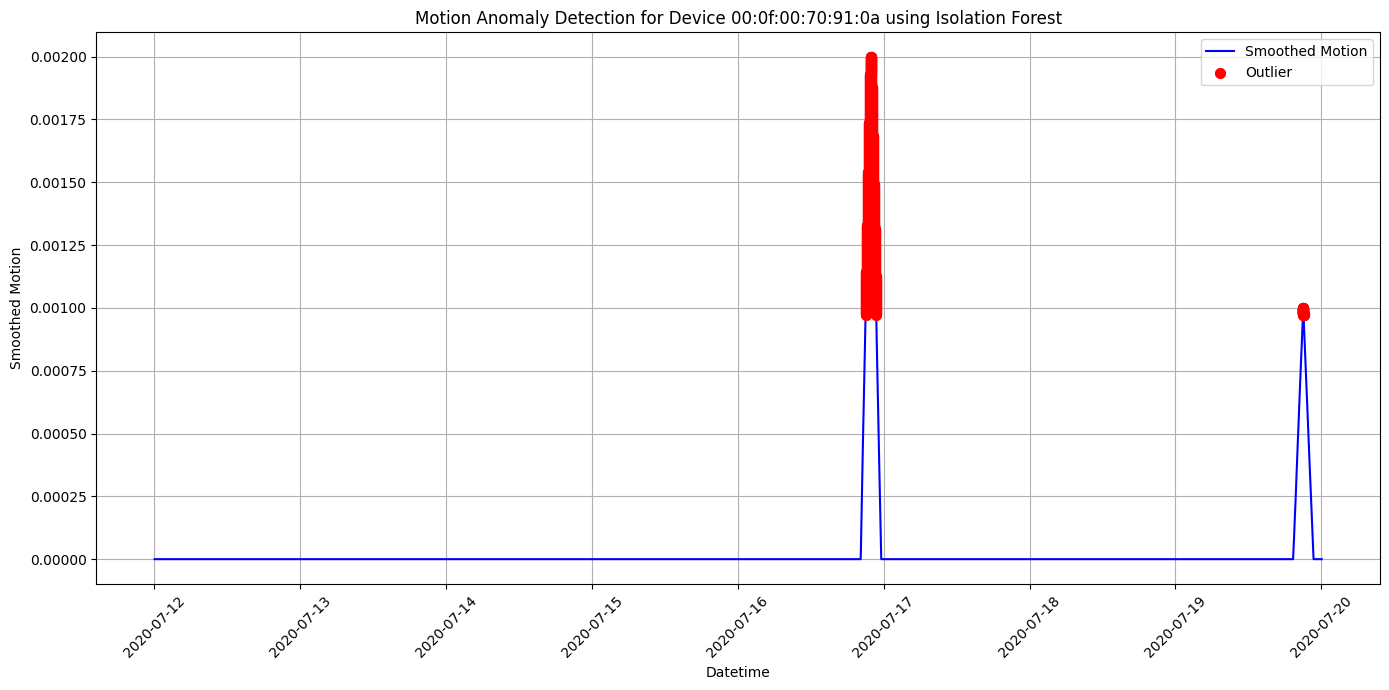

In [ ]:
# Select data for device '00:0f:00:70:91:0a' and 'temp' sensor
device_id_to_analyze = '00:0f:00:70:91:0a' #'1c:bf:ce:15:ec:4d'#
motion_data = device_df[device_id_to_analyze]['motion'] # Corrected to 'temp' from 'motion'

# Apply rolling mean smoothing to the temperature data
# Using a window size of 1000, similar to the binary data transformation
window_size = 1000
smoothed_motion = motion_data.rolling(window=window_size, min_periods=1).mean().dropna()

# Prepare data for Isolation Forest (needs a 2D array)
X = smoothed_motion.values.reshape(-1, 1)

# Initialize and train the Isolation Forest model
# contamination is the proportion of outliers in the data set
iso_forest = IsolationForest(random_state=42, contamination=0.01)
iso_forest.fit(X)

# Predict anomalies (-1 for outliers, 1 for inliers)
anomalies = iso_forest.predict(X)

# Add anomaly predictions back to the smoothed_temp series for plotting
smoothed_motion_anomalies = smoothed_motion.copy()
smoothed_motion_anomalies = pd.DataFrame(smoothed_motion_anomalies)
smoothed_motion_anomalies['anomaly'] = anomalies

# Plot the smoothed temperature data and highlight outliers
plt.figure(figsize=(14, 7))
plt.plot(smoothed_motion_anomalies.index, smoothed_motion_anomalies['motion'], label='Smoothed Motion', color='blue')

# Plot outliers
outliers = smoothed_motion_anomalies[smoothed_motion_anomalies['anomaly'] == -1]
plt.scatter(outliers.index, outliers['motion'], color='red', label='Outlier', s=50, zorder=3)

plt.title(f'Motion Anomaly Detection for Device {device_id_to_analyze} using Isolation Forest')
plt.xlabel('Datetime')
plt.ylabel('Smoothed Motion')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()